In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', 30)

In [ ]:
columns = ['engine_id', 'cycle'] + \
          [f'op_setting_{i}' for i in range(1, 4)] + \
          [f's{i}' for i in range(1, 22)]

train = pd.read_csv('../data/raw/train_FD001.txt', 
                    sep=r'\s+', header=None, names=columns)
test = pd.read_csv('../data/raw/test_FD001.txt', 
                   sep=r'\s+', header=None, names=columns)
rul_test = pd.read_csv('../data/raw/RUL_FD001.txt', 
                       sep=r'\s+', header=None, names=['RUL'])

print(f"Train: {train.shape}, {train['engine_id'].nunique()} engines")
print(f"Test:  {test.shape}, {test['engine_id'].nunique()} engines")
train.head()

Train: (20631, 26), 100 engines
Test:  (13096, 26), 100 engines


,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,s1,s2,s3,s4,s5,s6,s7,s8,s9,s10,s11,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: cycle, dtype: float64


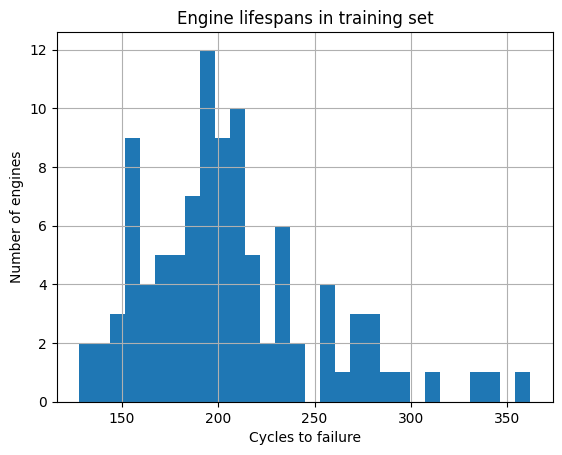

In [4]:
# How long does each engine run before failing in the training set?
engine_lifespans = train.groupby('engine_id')['cycle'].max()
print(engine_lifespans.describe())

engine_lifespans.hist(bins=30)
plt.xlabel('Cycles to failure')
plt.ylabel('Number of engines')
plt.title('Engine lifespans in training set');

In [5]:
print("Shortest lived engines:")
print(engine_lifespans.nsmallest(5))

print("\nLongest lived engines:")
print(engine_lifespans.nlargest(5))

Shortest lived engines:
engine_id
39    128
91    135
57    137
70    137
24    147
Name: cycle, dtype: int64

Longest lived engines:
engine_id
69    362
92    341
96    336
67    313
83    293
Name: cycle, dtype: int64


In [6]:
# Compute RUL for each row in training data
max_cycles = train.groupby('engine_id')['cycle'].max().reset_index()
max_cycles.columns = ['engine_id', 'max_cycle']

train = train.merge(max_cycles, on='engine_id')
train['RUL'] = train['max_cycle'] - train['cycle']
train = train.drop(columns=['max_cycle'])

# Quick check
print(train[['engine_id', 'cycle', 'RUL']].head(10))
print(f"\nRUL range: {train['RUL'].min()} to {train['RUL'].max()}")

   engine_id  cycle  RUL
0          1      1  191
1          1      2  190
2          1      3  189
3          1      4  188
4          1      5  187
5          1      6  186
6          1      7  185
7          1      8  184
8          1      9  183
9          1     10  182

RUL range: 0 to 361


Sensor standard deviations:
s1     0.000000e+00
s19    0.000000e+00
s18    0.000000e+00
s10    0.000000e+00
s16    3.469531e-18
s5     5.329200e-15
s6     1.388985e-03
s15    3.750504e-02
s8     7.098548e-02
s13    7.191892e-02
s21    1.082509e-01
s20    1.807464e-01
s11    2.670874e-01
s2     5.000533e-01
s12    7.375534e-01
s7     8.850923e-01
s17    1.548763e+00
s3     6.131150e+00
s4     9.000605e+00
s14    1.907618e+01
s9     2.208288e+01
dtype: float64


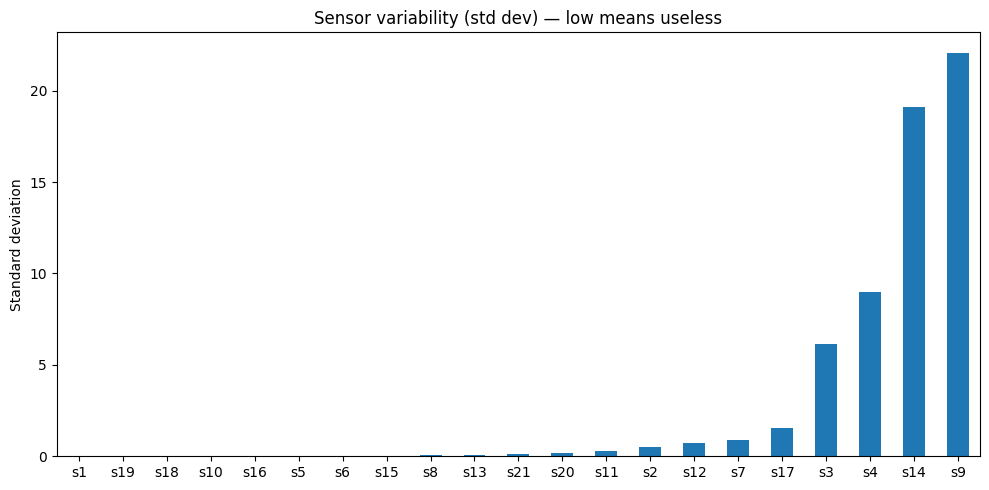


Useless sensors (flat lines): ['s1', 's5', 's6', 's10', 's16', 's18', 's19']
Useful sensors: ['s2', 's3', 's4', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21']


In [7]:
# Compute standard deviation of each sensor across all rows
sensor_cols = [f's{i}' for i in range(1, 22)]
sensor_stds = train[sensor_cols].std()

print("Sensor standard deviations:")
print(sensor_stds.sort_values())

# Visualize it
plt.figure(figsize=(10, 5))
sensor_stds.sort_values().plot(kind='bar')
plt.title('Sensor variability (std dev) — low means useless')
plt.ylabel('Standard deviation')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Identify useless sensors
useless = sensor_stds[sensor_stds < 0.01].index.tolist()
useful = sensor_stds[sensor_stds >= 0.01].index.tolist()
print(f"\nUseless sensors (flat lines): {useless}")
print(f"Useful sensors: {useful}")

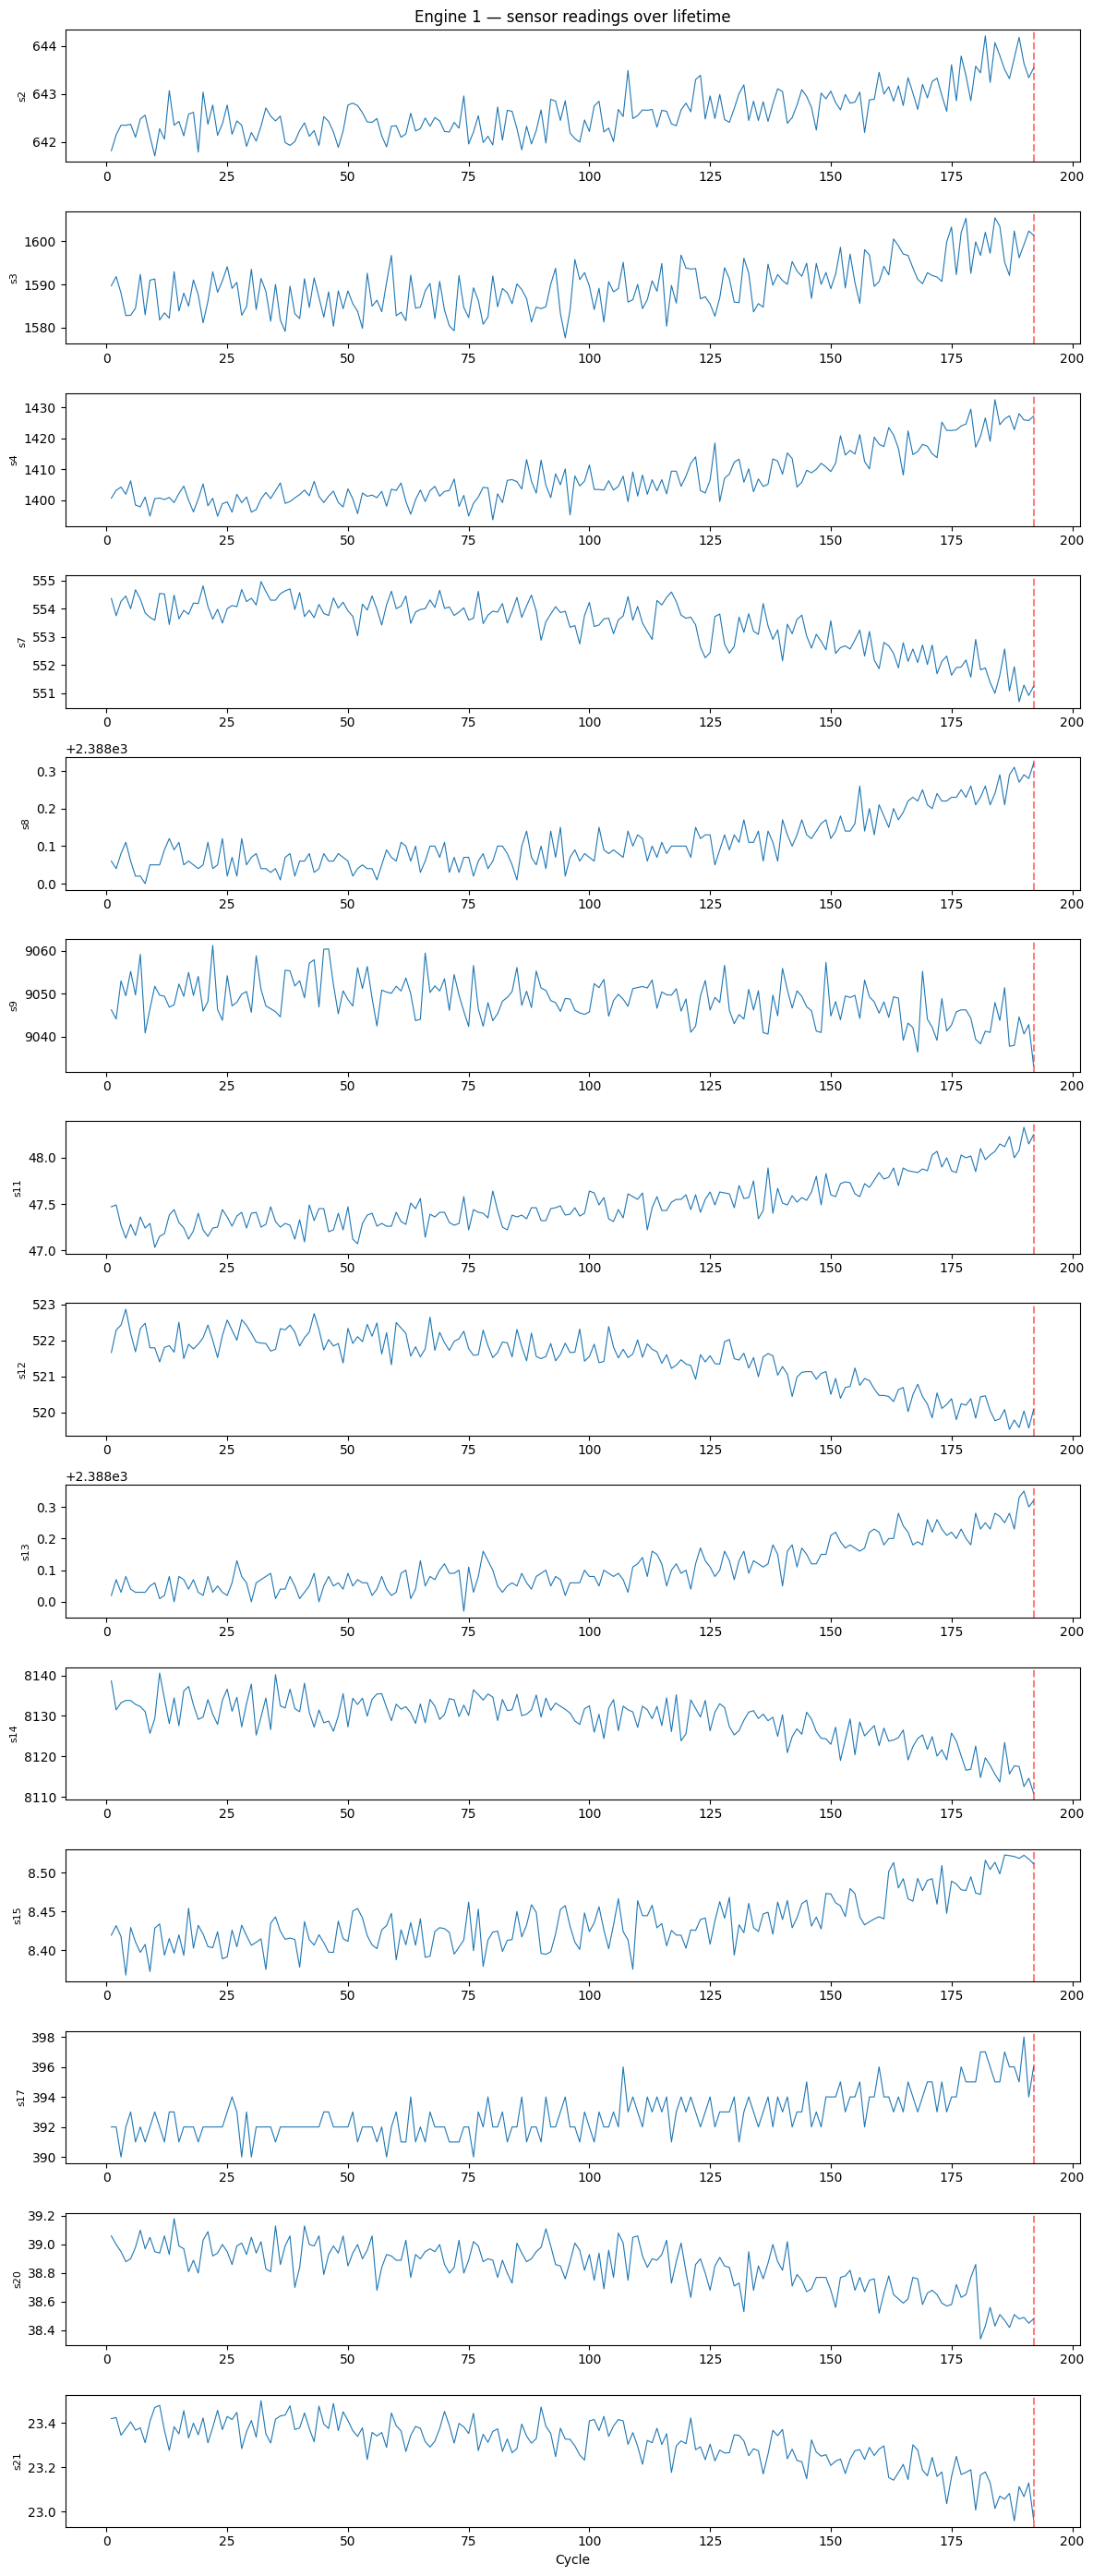

In [8]:
engine_id = 1
engine_data = train[train['engine_id'] == engine_id].sort_values('cycle')

fig, axes = plt.subplots(len(useful), 1, figsize=(12, len(useful) * 2))

for i, sensor in enumerate(useful):
    axes[i].plot(engine_data['cycle'], engine_data[sensor], linewidth=0.8)
    axes[i].set_ylabel(sensor, fontsize=8)
    axes[i].axvline(engine_data['cycle'].max(), color='red', 
                    linestyle='--', alpha=0.5, label='failure')
    
axes[0].set_title(f'Engine {engine_id} — sensor readings over lifetime')
axes[-1].set_xlabel('Cycle')
plt.tight_layout()
plt.show()

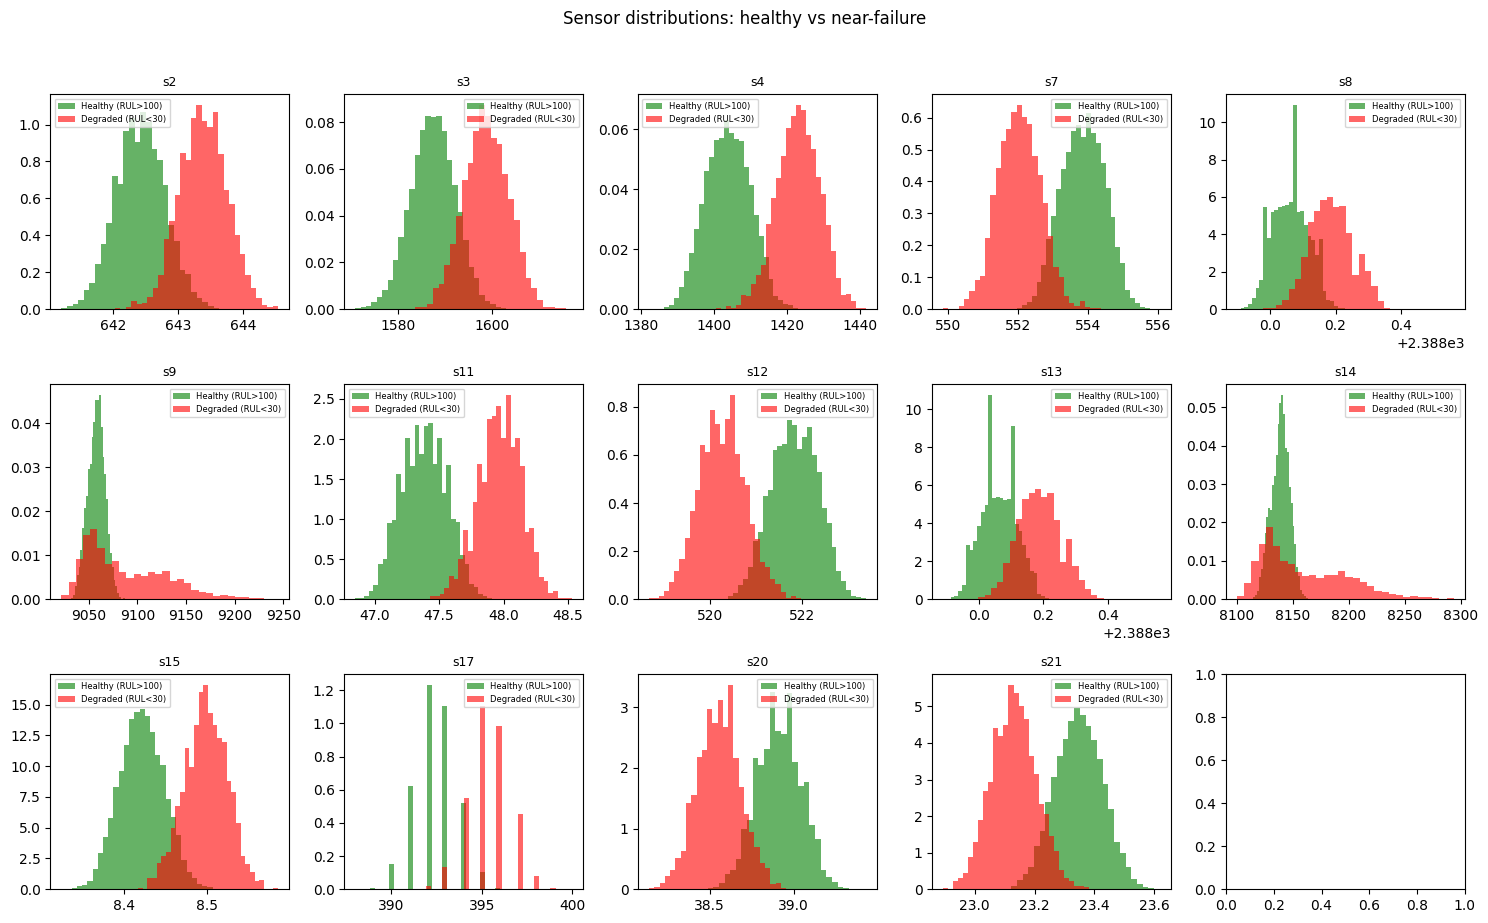

In [9]:
healthy = train[train['RUL'] > 100]
degraded = train[train['RUL'] < 30]

fig, axes = plt.subplots(3, 5, figsize=(15, 9))
axes = axes.flatten()

for i, sensor in enumerate(useful[:14]):
    axes[i].hist(healthy[sensor], bins=30, alpha=0.6, 
                 label='Healthy (RUL>100)', color='green', density=True)
    axes[i].hist(degraded[sensor], bins=30, alpha=0.6, 
                 label='Degraded (RUL<30)', color='red', density=True)
    axes[i].set_title(sensor, fontsize=9)
    axes[i].legend(fontsize=6)

plt.suptitle('Sensor distributions: healthy vs near-failure', y=1.02)
plt.tight_layout()
plt.show()

* s11,s4,s7,s12,s15,s20 shows the clearest seperation


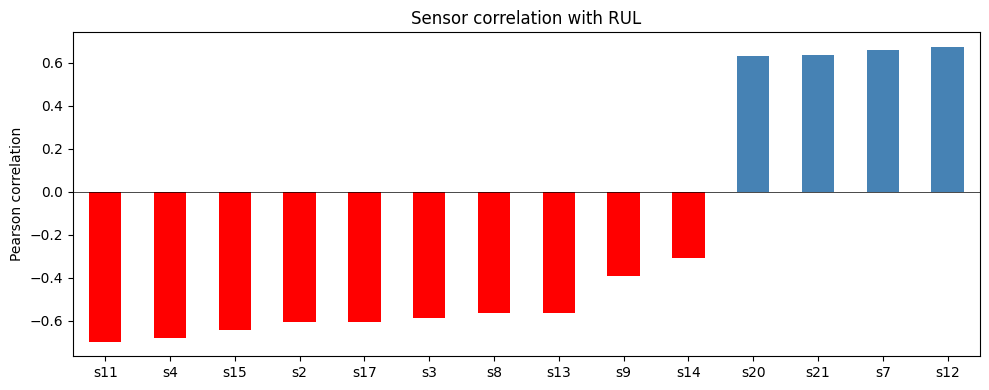

Strongest positive correlations with RUL (sensor goes DOWN as engine degrades):
s12    0.671983
s7     0.657223
s21    0.635662
s20    0.629428
s14   -0.306769
Name: RUL, dtype: float64

Strongest negative correlations with RUL (sensor goes UP as engine degrades):
s11   -0.696228
s4    -0.678948
s15   -0.642667
s2    -0.606484
s17   -0.606154
Name: RUL, dtype: float64


In [10]:
correlations = train[useful + ['RUL']].corr()['RUL'].drop('RUL')

plt.figure(figsize=(10, 4))
correlations.sort_values().plot(kind='bar', color=[
    'red' if x < 0 else 'steelblue' for x in correlations.sort_values()
])
plt.title('Sensor correlation with RUL')
plt.ylabel('Pearson correlation')
plt.axhline(0, color='black', linewidth=0.5)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("Strongest positive correlations with RUL (sensor goes DOWN as engine degrades):")
print(correlations.sort_values(ascending=False).head(5))
print("\nStrongest negative correlations with RUL (sensor goes UP as engine degrades):")
print(correlations.sort_values().head(5))

Plotting strongest sensor: s11


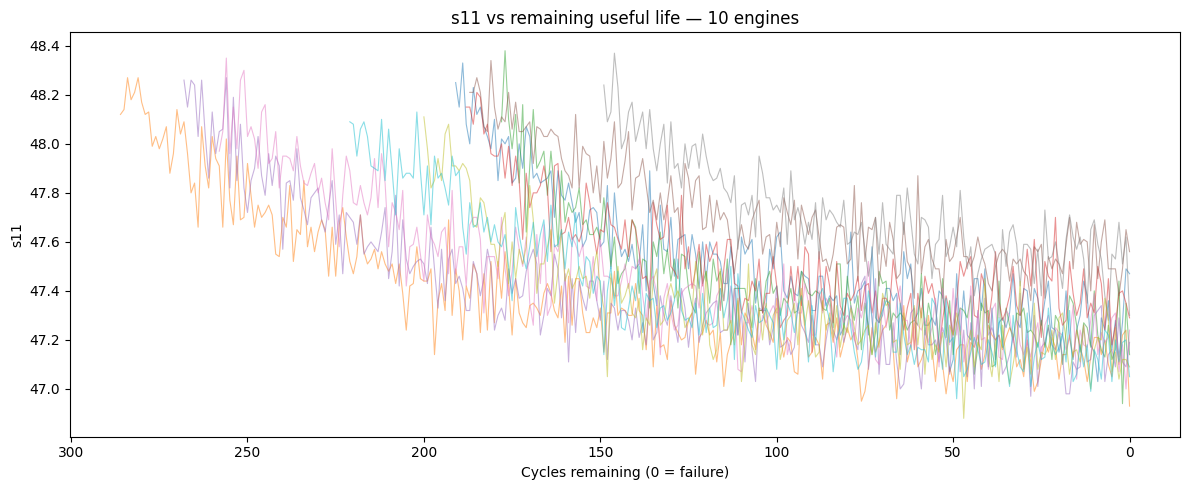

In [11]:
best_sensor = correlations.abs().sort_values(ascending=False).index[0]
print(f"Plotting strongest sensor: {best_sensor}")

plt.figure(figsize=(12, 5))

for eid in train['engine_id'].unique()[:10]:
    engine = train[train['engine_id'] == eid].sort_values('cycle')
    plt.plot(engine['RUL'].values[::-1],  # flip so x=0 is start of life
             engine[best_sensor].values, 
             alpha=0.5, linewidth=0.8)

plt.xlabel('Cycles remaining (0 = failure)')
plt.ylabel(best_sensor)
plt.title(f'{best_sensor} vs remaining useful life — 10 engines')
plt.gca().invert_xaxis()  # failure on the right
plt.tight_layout()
plt.show()

* dropped these sensors (s1, s5, s6, s10, s16, s18, s19) because because the shows the same value across every single cycle for every single engine

* for most of the run, sensor values look fairly stable (normal wear/noise). Closer to failure, the curves start to show a consistent trend (for example, drifting up or down faster), and that trend becomes obvious in roughly the last few dozen cycles. That’s the point where the model can start distinguishing “normal” vs “approaching failure” more reliably.